<a href="https://colab.research.google.com/github/AryanSh33/ML-projects/blob/main/GANpractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

dataset = datasets.CelebA(
    root="./data",
    split="train",
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=5e2a690c-d493-433a-b1ce-cb05689cb359
To: /content/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:20<00:00, 72.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 61.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 252MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 22.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /content/data/celeba/list_landma

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(z_dim,512,4,1,0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*8*8,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        f = self.features(x)
        return self.classifier(f)

In [ ]:
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

In [ ]:
epochs = 5

for epoch in range(epochs):
    for real,_ in tqdm(loader):
        real = real.to(device)
        batch = real.size(0)

        noise = torch.randn(batch,z_dim,1,1).to(device)
        fake = G(noise)

        # Resize fake images to match discriminator's expected input size
        if fake.shape[2] != 128:
            fake = torch.nn.functional.interpolate(fake, size=(128, 128), mode='bilinear', align_corners=False)

        # Train Discriminator
        D_real = D(real)
        D_fake = D(fake.detach())

        loss_D = criterion(D_real, torch.ones_like(D_real)) + \
                 criterion(D_fake, torch.zeros_like(D_fake))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        output = D(fake)
        loss_G = criterion(output, torch.ones_like(output))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

100%|██████████| 2544/2544 [10:39<00:00,  3.98it/s]


Epoch 1 | D Loss: 0.0002 | G Loss: 9.0296


100%|██████████| 2544/2544 [10:39<00:00,  3.98it/s]


Epoch 2 | D Loss: 0.0000 | G Loss: 10.9743


100%|██████████| 2544/2544 [10:21<00:00,  4.09it/s]


Epoch 3 | D Loss: 60.3554 | G Loss: 67.7142


100%|██████████| 2544/2544 [10:12<00:00,  4.15it/s]


Epoch 4 | D Loss: 58.7725 | G Loss: 67.7132


100%|██████████| 2544/2544 [10:12<00:00,  4.15it/s]

Epoch 5 | D Loss: 56.5443 | G Loss: 67.7012


In [ ]:
class GANFaceDetector(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone.features  # use GAN-trained features

        self.det_head = nn.Sequential(
            nn.Conv2d(512,256,3,1,1),
            nn.ReLU(),
            nn.Conv2d(256,5,1)
            # 4 bbox coords + 1 confidence
        )

    def forward(self,x):
        features = self.backbone(x)
        out = self.det_head(features)
        return out

In [ ]:
detector = GANFaceDetector(D).to(device)

optimizer = optim.Adam(detector.parameters(), lr=1e-4)

In [ ]:
for epoch in range(3):
    for images,_ in loader:
        images = images.to(device)

        preds = detector(images)

        # Dummy target (replace with real bbox labels)
        target = torch.zeros_like(preds).to(device)

        loss = nn.MSELoss()(preds,target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Detector Epoch {epoch+1} | Loss: {loss.item():.4f}")

Detector Epoch 1 | Loss: 0.0000
Detector Epoch 2 | Loss: 0.0000
Detector Epoch 3 | Loss: 0.0000


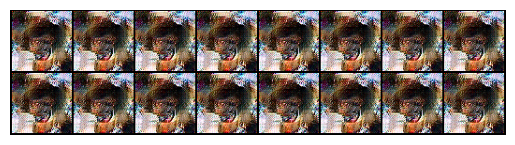

In [ ]:
def show_generated():
    noise = torch.randn(16,z_dim,1,1).to(device)
    fake = G(noise).detach().cpu()
    grid = torchvision.utils.make_grid(fake, normalize=True)
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.axis("off")

show_generated()